# Tutorial 2 — Mini-VPD: Decomposing a Network's Weights into Mechanisms

**Companion notebook, Part 2 of 2.** Released to attendees after the talk.

Tutorial 1 worked in *activation space*: reading and writing concepts as directions in
the data flowing through a frozen model. This notebook works in *weight space*: we take
a frozen network and learn a **parameter decomposition** — every weight matrix
re-expressed as a sum of rank-1 "components" — plus a **causal importance (CI)
function** that says, per datapoint, which components are doing the work. The training
objective makes a strong promise: *any component the CI function labels unimportant can
be ablated — even adversarially — without changing the model's output.*

This is a faithful miniature of **adVersarial Parameter Decomposition (VPD)** from
Goodfire AI (*Interpreting LM Parameters*, April 2026; code: `goodfire-ai/param-decomp`,
whose single-file reference `nano_param_decomp/run.py` this notebook is modeled on),
which builds on SPD (Braun et al., arXiv:2506.20790).

**Important framing.** The target here is a *toy two-layer MLP on synthetic sparse
data* — chosen because its ground-truth mechanisms are known by construction, so you
can *see* the decomposition find them. The real method decomposes transformer LMs
(attention + MLP weights) with a transformer-based CI function and KL reconstruction on
logits; the mapping to scale is spelled out at the end. Training runs are deliberately
short; all figures are real outputs of this notebook. Runs on GPU when available.

In [1]:
import math
from typing import Literal

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

device: cuda (NVIDIA GeForce RTX 5070)


## 1. A target network whose mechanisms we know

Task: inputs have 16 features, each independently active with probability 0.1 (value
uniform in [-1, 1], zero otherwise). The function to learn is elementwise
`y = ReLU(x)`. A 16→32→16 ReLU MLP solves this with one tiny, *separable* mechanism per
feature: route feature i to its own hidden unit(s), then back to output i. That gives us
ground truth: a good decomposition should discover ~16 components per weight matrix, one
per feature — and we can check it, because we know the answer.

We train the target briefly, then **freeze it forever**. VPD never touches these weights.

In [2]:
D_IN, D_HID = 16, 32


def sample_batch(B: int, active_p: float = 0.1) -> torch.Tensor:
    active = torch.rand(B, D_IN, device=device) < active_p
    vals = torch.rand(B, D_IN, device=device) * 2 - 1
    return torch.where(active, vals, torch.zeros((), device=device)).float()


class TargetMLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.w_in = nn.Linear(D_IN, D_HID, bias=False)
        self.w_out = nn.Linear(D_HID, D_IN, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w_out(F.relu(self.w_in(x)))


target = TargetMLP().to(device)
opt = torch.optim.Adam(target.parameters(), lr=3e-3)
for step in range(4000):
    x = sample_batch(1024)
    loss = F.mse_loss(target(x), F.relu(x))
    opt.zero_grad()
    loss.backward()
    opt.step()
print(f"target trained: final task MSE = {loss.item():.2e}")

x_test = sample_batch(4000)
broken_mse = F.mse_loss(torch.zeros_like(x_test), F.relu(x_test)).item()
print(f"(for scale: a fully-broken model that outputs zeros scores MSE = {broken_mse:.2e})")

for p in target.parameters():
    p.requires_grad_(False)
target.eval()

target trained: final task MSE = 1.95e-14
(for scale: a fully-broken model that outputs zeros scores MSE = 1.65e-02)


TargetMLP(
  (w_in): Linear(in_features=16, out_features=32, bias=False)
  (w_out): Linear(in_features=32, out_features=16, bias=False)
)

## 2. The decomposition machinery

Three pieces, mirroring Sections B–D of `nano_param_decomp/run.py`:

**(a) `ComponentLinear`** replaces each frozen linear layer. It holds the frozen target
weight `W` plus trainable matrices `V` (d_in × C) and `U` (C × d_out); component c is
the rank-1 matrix formed from column c of V and row c of U, and the components should
sum back to `W`. Whatever they don't yet explain lives in the **weight delta**
`W − (V·U)ᵀ`, treated as one extra ablatable "spillover" component. In component mode
the forward is: component activations `x·V`, gated per-sample by a mask over C, then
mapped out through `U`, plus the delta path gated by its own scalar mask.

**(b) The CI function** — here a small MLP (the real method uses a shared transformer) —
reads the (RMS-normed, concatenated) *inputs* of every decomposed layer from the clean
forward pass, and outputs one importance score in [0,1] per component per sample, via
hard-sigmoid squashings with leaky straight-through gradients.

**(c) The mask convention** — the heart of the method. Ablation masks are always drawn
from the box `m = ci + (1 − ci) · s` with `s ∈ [0,1]`: a component with ci = 1 is
protected (mask pinned at 1); a component with ci = 0 is fair game (mask anywhere in
[0,1]). Training will demand the output survive **any** mask in that box.

In [3]:
class ComponentLinear(nn.Module):
    """Replaces one frozen nn.Linear with C rank-1 components + a delta path."""

    def __init__(self, linear: nn.Linear, C: int) -> None:
        super().__init__()
        d_out, d_in = linear.weight.shape
        self.C = C
        self.register_buffer("W_target", linear.weight.detach().clone())
        self.V = nn.Parameter(torch.empty(d_in, C).normal_(0.0, 1.0 / math.sqrt(d_in)))
        self.U = nn.Parameter(torch.empty(C, d_out).normal_(0.0, 1.0 / math.sqrt(C)))
        self.mode: Literal["target", "component"] = "target"
        self.mask: torch.Tensor | None = None          # [B, C]
        self.delta_mask: torch.Tensor | None = None    # [B]
        self.routing: torch.Tensor | None = None       # [B] bool; None = component everywhere
        self.last_input: torch.Tensor | None = None

    def weight_delta(self) -> torch.Tensor:
        return self.W_target - (self.V @ self.U).T

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.mode == "target":
            self.last_input = x.detach()
            return F.linear(x, self.W_target)
        assert self.mask is not None and self.delta_mask is not None
        comp_out = ((x @ self.V) * self.mask) @ self.U
        comp_out = comp_out + self.delta_mask[:, None] * F.linear(x, self.weight_delta())
        if self.routing is not None:
            comp_out = torch.where(
                self.routing[:, None], comp_out, F.linear(x, self.W_target)
            )
        return comp_out


C_PER_SITE = 20  # >16 needed mechanisms; importance-minimality should kill the surplus
sites = {
    "w_in": ComponentLinear(target.w_in, C_PER_SITE),
    "w_out": ComponentLinear(target.w_out, C_PER_SITE),
}
target.w_in, target.w_out = sites["w_in"], sites["w_out"]
target.to(device)
SITE_NAMES = list(sites)
print("installed ComponentLinear on:", SITE_NAMES)


class _LowerLeaky(torch.autograd.Function):
    """clamp(x,0,1); below 0, pass gradient only when it would resurrect the component."""

    @staticmethod
    def forward(ctx, x, alpha):
        ctx.save_for_backward(x)
        ctx.alpha = alpha
        return x.clamp(0.0, 1.0)

    @staticmethod
    def backward(ctx, g):
        (x,) = ctx.saved_tensors
        zero = torch.zeros_like(g)
        grad = torch.where(
            x <= 0,
            torch.where(g < 0, ctx.alpha * g, zero),
            torch.where(x <= 1, g, zero),
        )
        return grad, None


def lower_leaky(x: torch.Tensor, alpha: float = 0.01) -> torch.Tensor:
    return _LowerLeaky.apply(x, alpha)


def upper_leaky(x: torch.Tensor, alpha: float = 0.01) -> torch.Tensor:
    return torch.where(x > 1, 1 + alpha * (x - 1), x.clamp(0.0, 1.0))


class CIFunction(nn.Module):
    """Reads all sites' input activations, emits per-component importances in [0,1]."""

    def __init__(self, d_ins: list[int], cs: list[int], d_hidden: int = 256) -> None:
        super().__init__()
        self.cs = cs
        self.net = nn.Sequential(
            nn.Linear(sum(d_ins), d_hidden), nn.GELU(),
            nn.Linear(d_hidden, d_hidden), nn.GELU(),
            nn.Linear(d_hidden, sum(cs)),
        )

    def forward(self, acts: list[torch.Tensor]):
        normed = [a / (a.pow(2).mean(-1, keepdim=True).sqrt() + 1e-6) for a in acts]
        logits = self.net(torch.cat(normed, dim=-1))
        per_site = logits.split(self.cs, dim=-1)
        ci_lower = [lower_leaky(l) for l in per_site]   # used to build masks
        ci_upper = [upper_leaky(l) for l in per_site]   # used by the minimality penalty
        return ci_lower, ci_upper


ci_fn = CIFunction([D_IN, D_HID], [C_PER_SITE, C_PER_SITE]).to(device)
print(f"CI function: {sum(p.numel() for p in ci_fn.parameters()):,} params")

installed ComponentLinear on: ['w_in', 'w_out']
CI function: 88,616 params


## 3. The four losses and the adversary

| Loss | Plain-English demand | Coefficient |
|---|---|---|
| **Faithfulness** | the components must sum back to the original weights | large |
| **Importance minimality** | the CI function must mark as few components important as possible (Lp with p annealed 2 → 0.4, plus a description-length term that consolidates duplicates) | small |
| **Stochastic reconstruction** | *random* masks from the allowed box must not change the output | 1 |
| **Adversarial reconstruction** | the *worst-case* mask a PGD adversary can find in the box must not change the output | 1 |

The adversary here is the **fresh sign-PGD** variant (`PGDReconLoss` in the real repo:
sources re-initialized each step, a few sign-gradient ascent steps, clamped to [0,1]);
the flagship runs use *persistent* PGD with Adam state carried across steps — same box,
stronger attacker. The minimax structure is identical: the adversary ascends the same
reconstruction loss the decomposition descends. Reconstruction is MSE on outputs here
because the toy task is regression; for an LM it is KL on logits.

In [4]:
def set_masks(masks, delta_masks, routing) -> None:
    for i, name in enumerate(SITE_NAMES):
        s = sites[name]
        s.mode = "component"
        s.mask = masks[i]
        s.delta_mask = delta_masks[i]
        s.routing = None if routing is None else routing[i]


def clear_masks() -> None:
    for s in sites.values():
        s.mode = "target"
        s.mask = s.delta_mask = s.routing = None


def faithfulness_loss() -> torch.Tensor:
    total, numel = 0.0, 0
    for s in sites.values():
        delta = s.weight_delta()
        total = total + delta.pow(2).sum()
        numel += delta.numel()
    return total / numel


def importance_minimality_loss(ci_upper, p: float, beta: float = 0.5,
                               eps: float = 1e-12) -> torch.Tensor:
    """Per component: mean(ci^p) + beta * mean(ci^p) * log2(1 + total usage).
    The log term is nano-VPD's description-length pressure: it bears hardest on
    components used often, so duplicated/split mechanisms consolidate."""
    total = 0.0
    for ci in ci_upper:
        vals = (ci + eps).pow(p)
        sum_c = vals.sum(0)
        mean_c = vals.mean(0)
        total = total + (mean_c + beta * mean_c * torch.log2(1 + sum_c)).sum()
    return total


def masked_forward(x, masks, delta_masks, routing=None) -> torch.Tensor:
    set_masks(masks, delta_masks, routing)
    try:
        return target(x)
    finally:
        clear_masks()


def stochastic_recon_loss(x, y_clean, ci_lower) -> torch.Tensor:
    """Random masks from the box + random per-sample routing over a k-subset of sites."""
    B = x.shape[0]
    masks = [ci + (1 - ci) * torch.rand_like(ci) for ci in ci_lower]
    delta_masks = [torch.rand(B, device=device) for _ in SITE_NAMES]
    k = torch.randint(1, len(SITE_NAMES) + 1, (B,), device=device)
    ranks = torch.rand(len(SITE_NAMES), B, device=device).argsort(0).argsort(0)
    routing = [ranks[i] < k for i in range(len(SITE_NAMES))]
    return F.mse_loss(masked_forward(x, masks, delta_masks, routing), y_clean)


def adversarial_recon_loss(x, y_clean, ci_lower, n_steps: int = 5, step: float = 0.3):
    """Fresh sign-PGD: find the worst mask in the box, return the loss under it."""
    B = x.shape[0]
    sources = [torch.rand(B, s.C + 1, device=device, requires_grad=True) for s in sites.values()]

    def loss_from_sources(ci_list):
        masks = [ci + (1 - ci) * src[:, :-1] for ci, src in zip(ci_list, sources)]
        delta_masks = [src[:, -1] for src in sources]
        return F.mse_loss(masked_forward(x, masks, delta_masks), y_clean)

    ci_detached = [ci.detach() for ci in ci_lower]
    for _ in range(n_steps):  # ascent: only the sources move
        grads = torch.autograd.grad(loss_from_sources(ci_detached), sources)
        with torch.no_grad():
            for src, g in zip(sources, grads):
                src.add_(step * g.sign()).clamp_(0.0, 1.0)
    return loss_from_sources(ci_lower)  # final pass: gradients flow to V, U, CI

## 4. Training: faithfulness warmup, then the minimax loop

Step by step, each main-loop iteration is:
1. clean forward through the frozen target (caches each site's input activations),
2. CI function stamps every component with an importance score,
3. the adversary searches the allowed box for the nastiest ablation,
4. the four losses are combined,
5. components + CI function descend; (a persistent adversary would ascend here).

In [5]:
component_params = [p for s in sites.values() for p in (s.V, s.U)]

warmup_opt = torch.optim.AdamW(component_params, lr=3e-3, weight_decay=0.0)
for _ in range(500):
    warmup_opt.zero_grad()
    faithfulness_loss().backward()
    warmup_opt.step()
print(f"after faithfulness warmup: mean-sq weight delta = {faithfulness_loss().item():.2e}")

COEFF_FAITH, COEFF_IMP, COEFF_STOCH, COEFF_ADV = 3e4, 1e-3, 1.0, 3.0
N_STEPS, B = 16000, 1024
main_opt = torch.optim.AdamW(
    component_params + list(ci_fn.parameters()), lr=1e-3, weight_decay=0.0
)
history: dict[str, list[float]] = {"faith": [], "imp": [], "stoch": [], "adv": []}

for step in range(N_STEPS):
    lr_now = 1e-4 + 0.5 * (1e-3 - 1e-4) * (1 + math.cos(math.pi * step / N_STEPS))
    for g in main_opt.param_groups:
        g["lr"] = lr_now
    x = sample_batch(B)
    clear_masks()
    with torch.no_grad():
        y_clean = target(x)
    acts = [sites[n].last_input for n in SITE_NAMES]
    ci_lower, ci_upper = ci_fn(acts)

    p_now = 2.0 + (0.4 - 2.0) * step / N_STEPS
    l_faith = faithfulness_loss()
    l_imp = importance_minimality_loss(ci_upper, p_now)
    l_stoch = stochastic_recon_loss(x, y_clean, ci_lower)
    l_adv = adversarial_recon_loss(x, y_clean, ci_lower)
    total = (
        COEFF_FAITH * l_faith + COEFF_IMP * l_imp + COEFF_STOCH * l_stoch + COEFF_ADV * l_adv
    )
    main_opt.zero_grad()
    total.backward()
    main_opt.step()

    if step % 25 == 0:
        for k, v in zip(history, (l_faith, l_imp, l_stoch, l_adv)):
            history[k].append(v.item())
    if step % 3200 == 0 or step == N_STEPS - 1:
        print(
            f"step {step:5d}  faith={l_faith.item():.2e}  imp={l_imp.item():.2f}  "
            f"stoch={l_stoch.item():.2e}  adv={l_adv.item():.2e}  (p={p_now:.2f})"
        )

after faithfulness warmup: mean-sq weight delta = 5.79e-08


step     0  faith=5.79e-08  imp=0.13  stoch=8.73e-03  adv=4.24e-02  (p=2.00)


step  3200  faith=3.52e-09  imp=18.91  stoch=1.22e-03  adv=6.07e-03  (p=1.68)


step  6400  faith=1.90e-09  imp=18.38  stoch=9.18e-04  adv=4.58e-03  (p=1.36)


step  9600  faith=4.76e-10  imp=14.46  stoch=6.37e-04  adv=3.51e-03  (p=1.04)


step 12800  faith=6.27e-11  imp=12.49  stoch=4.14e-04  adv=2.28e-03  (p=0.72)


step 15999  faith=3.10e-11  imp=11.70  stoch=2.41e-04  adv=1.28e-03  (p=0.40)


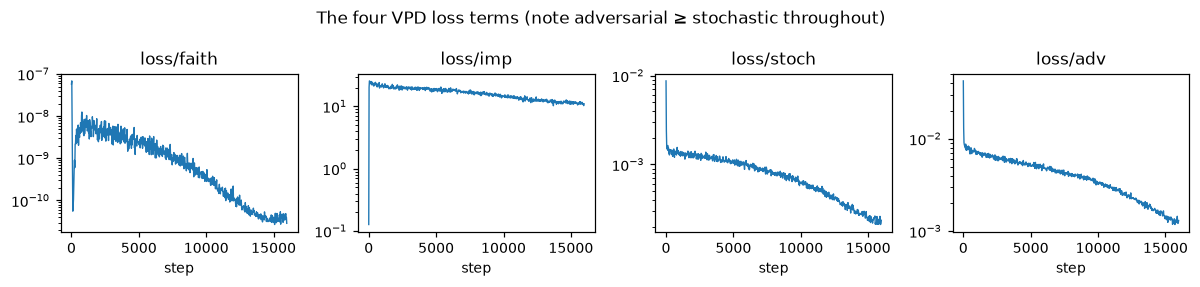

In [6]:
fig, axs = plt.subplots(1, 4, figsize=(11, 2.6))
for ax, (k, vals) in zip(axs, history.items()):
    ax.plot(np.arange(len(vals)) * 25, vals, lw=0.9)
    ax.set_yscale("log")
    ax.set_title(f"loss/{k}")
    ax.set_xlabel("step")
fig.suptitle("The four VPD loss terms (note adversarial ≥ stochastic throughout)")
fig.tight_layout()
plt.show()

## 5. Reading the decomposition: which components are alive, and what are they?

First, average importance per component over data — the pruning view. The
importance-minimality pressure should have killed the surplus components (we gave each
site 20; the task needs ~16).

Second, the mechanism view: feed batches where exactly **one** feature is active and
heat-map the CI scores. If the decomposition found the ground-truth structure, each
feature should light up its own small set of components — an approximate permutation
matrix, discovered with no supervision on mechanisms whatsoever.

w_in: mean components used per sample (CI > 0.5): 1.12
w_out: mean components used per sample (CI > 0.5): 1.49


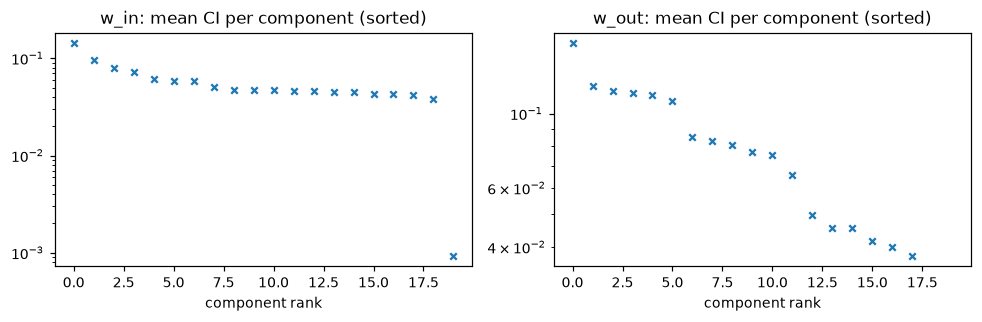

In [7]:
with torch.no_grad():
    clear_masks()
    xs = sample_batch(4000)
    _ = target(xs)
    ci_l, _ = ci_fn([sites[n].last_input for n in SITE_NAMES])
    mean_ci = [ci.mean(0) for ci in ci_l]

l0 = [float((ci > 0.5).float().sum(-1).mean()) for ci in ci_l]
fig, axs = plt.subplots(1, 2, figsize=(9, 3))
for ax, name, mc, l0_site in zip(axs, SITE_NAMES, mean_ci, l0):
    vals = mc.sort(descending=True).values.cpu().numpy()
    ax.scatter(range(len(vals)), vals, marker="x", s=18)
    ax.set_yscale("log")
    ax.set_title(f"{name}: mean CI per component (sorted)")
    ax.set_xlabel("component rank")
    print(f"{name}: mean components used per sample (CI > 0.5): {l0_site:.2f}")
fig.tight_layout()
plt.show()
# On sparse data (~1.6 active features per sample) an honest decomposition needs only a
# couple of components per sample — mean CI per component is low because each mechanism
# is *rarely relevant*, not because it is dead. The next figure separates the two.

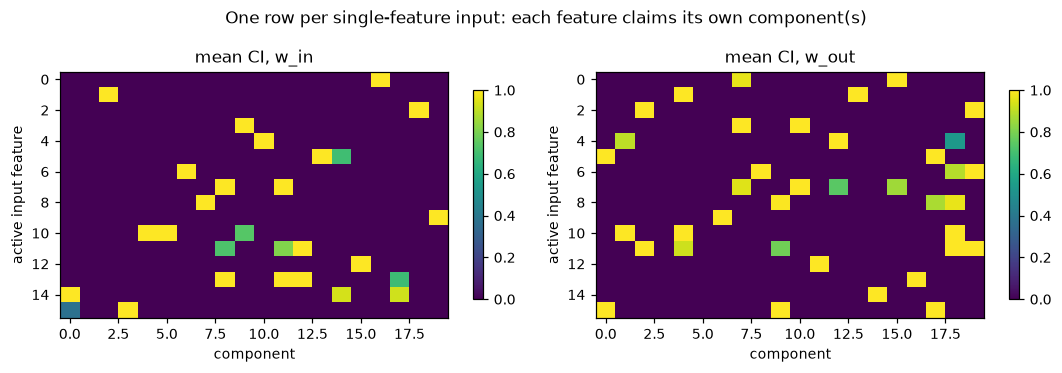

weakest feature's strongest component CI: 0.99 (1.0 = fully claimed)
w_in: 19/20 components claimed by at least one feature (the rest are surplus)
w_out: 18/20 components claimed by at least one feature (the rest are surplus)


In [8]:
def single_feature_batch(i: int, B: int = 256) -> torch.Tensor:
    x = torch.zeros(B, D_IN, device=device)
    x[:, i] = torch.rand(B, device=device) * 0.75 + 0.25  # positive, within training range
    return x


ci_by_feature = []  # [16, 2, C]
with torch.no_grad():
    for i in range(D_IN):
        clear_masks()
        _ = target(single_feature_batch(i))
        ci_l, _ = ci_fn([sites[n].last_input for n in SITE_NAMES])
        ci_by_feature.append(torch.stack([c.mean(0) for c in ci_l]))
ci_by_feature = torch.stack(ci_by_feature)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
for k, (ax, name) in enumerate(zip(axs, SITE_NAMES)):
    im = ax.imshow(ci_by_feature[:, k].cpu().numpy(), aspect="auto", cmap="viridis", vmin=0, vmax=1)
    ax.set_xlabel("component")
    ax.set_ylabel("active input feature")
    ax.set_title(f"mean CI, {name}")
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.suptitle("One row per single-feature input: each feature claims its own component(s)")
fig.tight_layout()
plt.show()

row_max = ci_by_feature.max(dim=-1).values.min().item()
print(f"weakest feature's strongest component CI: {row_max:.2f} (1.0 = fully claimed)")
for k, name in enumerate(SITE_NAMES):
    claimed = int(((ci_by_feature[:, k] > 0.5).any(dim=0)).sum())
    print(f"{name}: {claimed}/{C_PER_SITE} components claimed by at least one feature "
          f"(the rest are surplus)")

## 6. Surgery: deleting one mechanism, leaving the rest intact

The payoff demo — the toy version of "removing one ability by turning one knob"
(Goodfire's demo removed a 67M-parameter LM's German with a single component scale).

We pick input feature 7, look up which component each site's CI assigns to it, and
**ablate those components** (mask 0 for them, CI-mask for everything else, delta off).
Then we measure per-feature reconstruction error before and after. If the decomposition
is honest, the error should spike **only for feature 7**: its mechanism is gone, and
nothing else was touching those components.

feature 7 claims: w_in components [8, 11]; w_out components [7, 10, 12, 15]


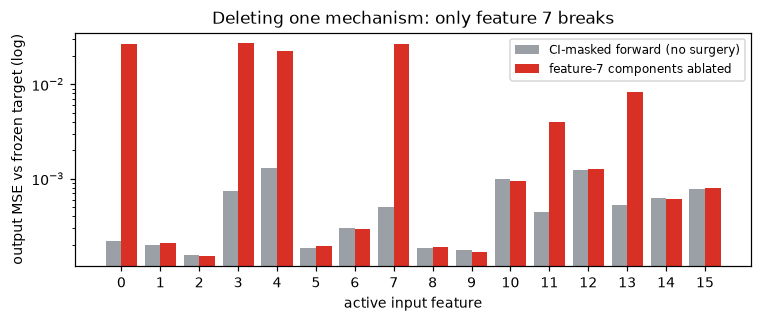

error on feature 7:  4.95e-04 → 2.68e-02
median error, other features: 4.46e-04 → 8.05e-04
(fully-broken baseline ≈ 1.65e-02)


In [9]:
FEATURE = 7
claimed_comps = [
    (ci_by_feature[FEATURE, k] > 0.5).nonzero().flatten().tolist()
    for k in range(len(SITE_NAMES))
]
print(f"feature {FEATURE} claims: "
      + "; ".join(f"{n} components {c}" for n, c in zip(SITE_NAMES, claimed_comps)))


def per_feature_errors(ablate: list[list[int]] | None) -> np.ndarray:
    errs = []
    with torch.no_grad():
        for i in range(D_IN):
            x = single_feature_batch(i)
            clear_masks()
            y_clean = target(x)
            ci_l, _ = ci_fn([sites[n].last_input for n in SITE_NAMES])
            masks = [ci.clone() for ci in ci_l]
            if ablate is not None:
                for k, comps in enumerate(ablate):
                    masks[k][:, comps] = 0.0
            delta_masks = [torch.zeros(x.shape[0], device=device) for _ in SITE_NAMES]
            pred = masked_forward(x, masks, delta_masks)
            errs.append(F.mse_loss(pred, y_clean).item())
    return np.array(errs)


err_before = per_feature_errors(ablate=None)
err_after = per_feature_errors(ablate=claimed_comps)

fig, ax = plt.subplots(figsize=(7, 3))
xpos = np.arange(D_IN)
ax.bar(xpos - 0.2, err_before, 0.4, label="CI-masked forward (no surgery)", color="#9aa0a6")
ax.bar(xpos + 0.2, err_after, 0.4,
       label=f"feature-{FEATURE} components ablated", color="#d93025")
ax.set_yscale("log")
ax.set_xlabel("active input feature")
ax.set_ylabel("output MSE vs frozen target (log)")
ax.set_title(f"Deleting one mechanism: only feature {FEATURE} breaks")
ax.set_xticks(xpos)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

others = np.delete(np.arange(D_IN), FEATURE)
print(f"error on feature {FEATURE}:  {err_before[FEATURE]:.2e} → {err_after[FEATURE]:.2e}")
print(f"median error, other features: {np.median(err_before[others]):.2e} → "
      f"{np.median(err_after[others]):.2e}")
print(f"(fully-broken baseline ≈ {broken_mse:.2e})")

## 7. Why the adversary? Random masks are too easy to fool

VPD's predecessor (SPD) only checked *random* ablations. The final experiment shows what
the adversary buys: on the trained decomposition, compare the reconstruction loss under
many random masks from the allowed box against the mask found by a 20-step PGD attack
(the eval-style attack from the reference implementation). The adversary reliably finds
worse masks than sampling ever stumbles on — during training, that gap is the signal
that forces the CI function to be *honest* about what is safe to ablate.

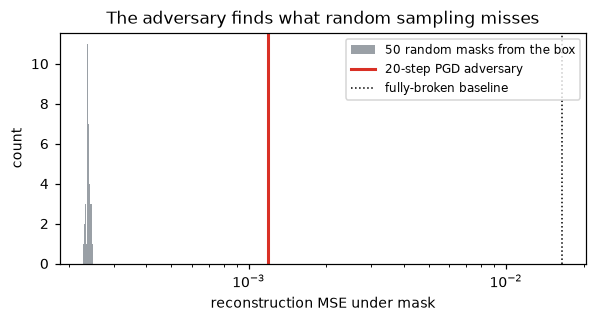

random masks: mean 2.38e-04 | PGD mask: 1.19e-03 | broken: 1.65e-02


In [10]:
x = sample_batch(2000)
clear_masks()
with torch.no_grad():
    y_clean = target(x)
    acts = [sites[n].last_input for n in SITE_NAMES]
    ci_l, _ = ci_fn(acts)

rand_losses = []
with torch.no_grad():
    for _ in range(50):
        masks = [ci + (1 - ci) * torch.rand_like(ci) for ci in ci_l]
        dm = [torch.rand(x.shape[0], device=device) for _ in SITE_NAMES]
        rand_losses.append(F.mse_loss(masked_forward(x, masks, dm), y_clean).item())

sources = [torch.rand(x.shape[0], s.C + 1, device=device, requires_grad=True) for s in sites.values()]
for _ in range(20):
    masks = [ci.detach() + (1 - ci.detach()) * src[:, :-1] for ci, src in zip(ci_l, sources)]
    dm = [src[:, -1] for src in sources]
    loss = F.mse_loss(masked_forward(x, masks, dm), y_clean)
    grads = torch.autograd.grad(loss, sources)
    with torch.no_grad():
        for src, g in zip(sources, grads):
            src.add_(0.1 * g.sign()).clamp_(0.0, 1.0)
with torch.no_grad():
    masks = [ci + (1 - ci) * src[:, :-1] for ci, src in zip(ci_l, sources)]
    dm = [src[:, -1] for src in sources]
    pgd_loss = F.mse_loss(masked_forward(x, masks, dm), y_clean).item()

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.hist(rand_losses, bins=15, color="#9aa0a6", label="50 random masks from the box")
ax.axvline(pgd_loss, color="#d93025", lw=2, label="20-step PGD adversary")
ax.axvline(broken_mse, color="k", ls=":", lw=1, label="fully-broken baseline")
ax.set_xlabel("reconstruction MSE under mask")
ax.set_ylabel("count")
ax.set_xscale("log")
ax.set_title("The adversary finds what random sampling misses")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"random masks: mean {np.mean(rand_losses):.2e} | PGD mask: {pgd_loss:.2e} "
      f"| broken: {broken_mse:.2e}")

## 8. What changes at scale

Everything you just ran is the real method, minus size. To go from this toy to the
published 4-layer LM decomposition (and the pipeline you'd run on your own model):

| This notebook | Full VPD (`goodfire-ai/param-decomp`) |
|---|---|
| 2-layer MLP target, MSE recon | frozen transformer LM, KL on logits |
| CI = small MLP per sample | CI = shared bidirectional transformer over all layers & positions |
| masks per sample | masks per (batch, position, component) |
| fresh 3-step sign-PGD | **persistent** PGD: per-position Adam adversary carried across steps |
| per-sample importance penalty | per-(batch, position) penalty over sequence data |
| 2 sites × 20 components | every attention/MLP matrix, thousands of components |
| this file | `nano_param_decomp/run.py` (torch reference) / `param_decomp/` (JAX trainer) |

After decomposition, the real pipeline harvests per-component statistics, auto-labels
components with an LLM, and clusters them into circuits (`pd-harvest`, `pd-autointerp`,
`pd-clustering`) — the machinery behind "erase one ability with one knob."

**References.** Goodfire AI, *Interpreting LM Parameters* (VPD), April 2026 —
`goodfire.ai/research/interpreting-lm-parameters`; Braun et al., *Stochastic Parameter
Decomposition*, arXiv:2506.20790; code: `github.com/goodfire-ai/param-decomp`.